In [1]:
import os
import h5py
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import yaml
import optax

In [2]:
import sys
sys.path.append('/Users/mariana/Documents/projects/Huawei/survan')

from lambda_cox import LambdaSA
from deep_lambda_cox import DeepLambdaSA
from baseline_cox import SA
from utils import concordance_index, unroll, get_single_task_dataset, kaplan_meier, unroll_time, score

In [3]:
from functools import partial

In [4]:
def score(beta, xs):
    return -jnp.dot(xs, beta)

In [5]:
config_path = '../configs/config_aids.yaml'
config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)

In [6]:
config['axis']

2

In [7]:
config['batch_size']

128

In [8]:
agent = SA(config, 42)
train_gen, test_gen = agent.get_train_test()

In [9]:
losses = agent.train(train_gen, test_gen)

In [10]:
train_loss, test_loss = losses

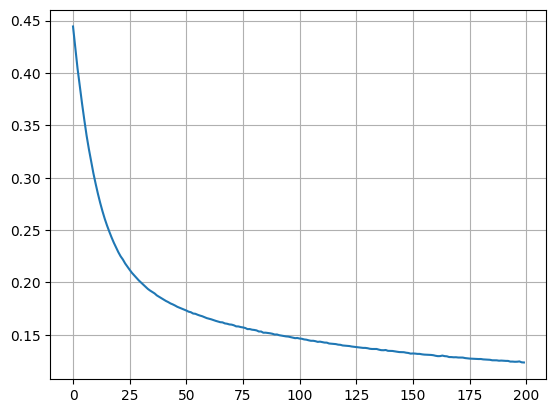

In [11]:
plt.plot(np.hstack(train_loss))
plt.grid()

In [12]:
agent.data['seqs'].shape

(467, 5, 5)

In [13]:
seqs = test_gen.X
ts = test_gen.ts
cs = test_gen.cs
ms = test_gen.mask

In [14]:
surv = agent.survival_curve(seqs)

In [15]:
surv_, ts_, cs_, ms_ = unroll_time(surv, ts, cs, ms, agent.horizon)

In [16]:
h = agent.horizon
aux = jnp.zeros(h).at[0].set(1)

In [17]:
jnp.tile(aux, 5)

Array([1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0.,
       0., 0., 0., 1., 0., 0., 0., 0.], dtype=float32)

In [18]:
def get_masks_initstate_ibs(h, n):
    aux = jnp.zeros(h).at[0].set(1)
    return jnp.tile(aux, n)

In [19]:
%%time

num_exps = 5
sizes = [.5, .4, .3, .25, .2, .1, .05]

res2_is = np.zeros((num_exps, len(sizes)))
res2_lm = np.zeros((num_exps, len(sizes)))

res3_is = np.zeros((num_exps, len(sizes)))
res3_lm = np.zeros((num_exps, len(sizes)))

for fold in range(num_exps):
    for i, size in enumerate(sizes):
        
        print(".", end="")
        
        # Initial state.
        config['landmark'] = False
        model = SA(config, seed=fold)
        
        train_gen, test_gen = model.get_train_test(test_size=size)
        seqs = test_gen.X
        ts = test_gen.ts
        cs = test_gen.cs
        
        _ = model.train(train_gen, test_gen)
        surv = model.survival_curve(seqs)
        res2_is[fold, i] = model.integrated_brier_score(surv[:,0], ts, cs)
        beta = model.state.params['cox_linear_model']['beta']
        seqs_ = seqs.reshape(-1, seqs.shape[-1])
        scores = score(beta, seqs[:,0])
        res3_is[fold, i] = concordance_index(scores, ts, cs)

        # Landmarking.
        config['landmark'] = True
        model = SA(config, seed=fold)
        
        train_gen, test_gen = model.get_train_test(test_size=size)
        seqs = test_gen.X
        ts = test_gen.ts
        cs = test_gen.cs
        ms = test_gen.mask
        
        _ = model.train(train_gen, test_gen)
        surv = model.survival_curve(seqs)
        res2_lm[fold, i] = model.integrated_brier_score(surv[:,0], ts, cs)
        beta = model.state.params['cox_linear_model']['beta']
        seqs_ = seqs.reshape(-1, seqs.shape[-1])
        scores = score(beta, seqs[:,0])
        res3_lm[fold, i] = concordance_index(scores, ts, cs)
        
    print()

.......
.......
.......
.......
.......
CPU times: user 33.2 s, sys: 1.53 s, total: 34.7 s
Wall time: 32.1 s


Text(0.5, 0, 'Test size proportion')

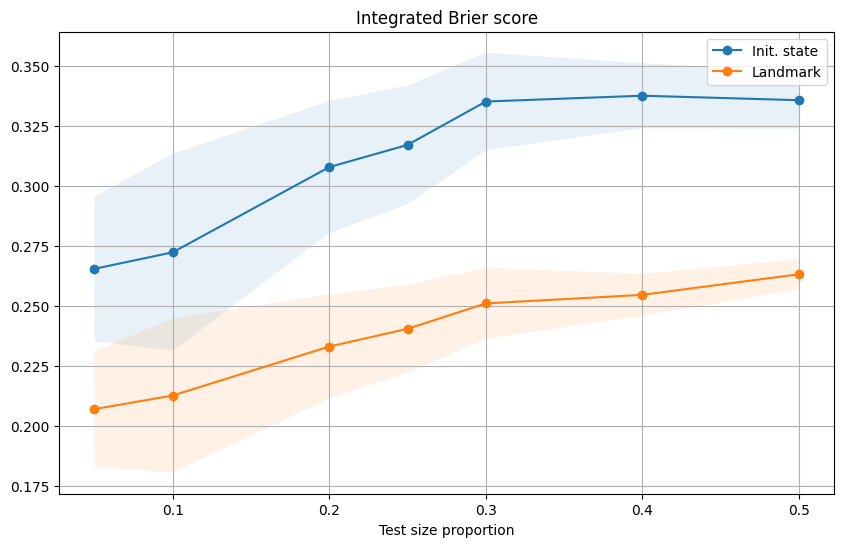

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))

for res, label in ((res2_is, "Init. state"), (res2_lm, "Landmark")):
    mean = res.mean(axis=0)
    std = res.std(axis=0) / np.sqrt(num_exps)
    ax.plot(sizes, mean, marker="o", label=label)
    ax.fill_between(sizes, mean - std, mean + std, alpha=0.1)

ax.legend()
ax.grid()
ax.set_title("Integrated Brier score")
ax.set_xlabel("Test size proportion")

Text(0.5, 0, 'Number of patients')

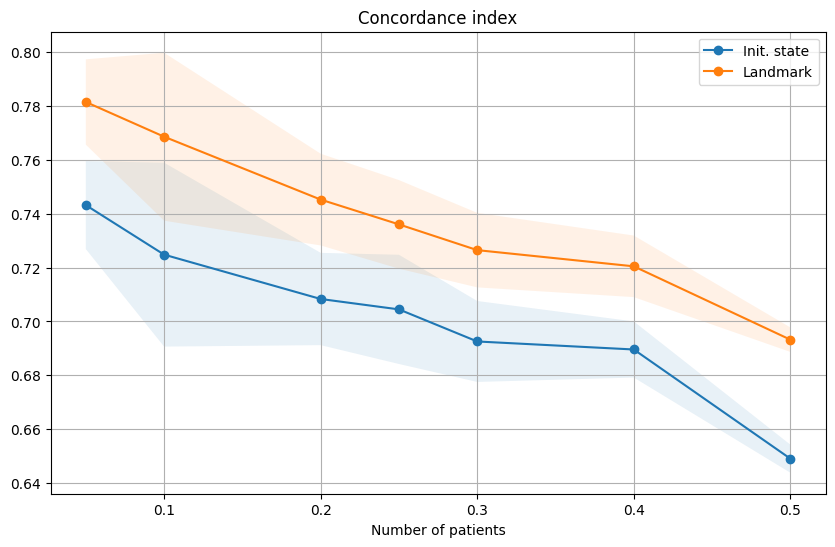

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))

for res, label in ((res3_is, "Init. state"), (res3_lm, "Landmark")):
    mean = res.mean(axis=0)
    std = res.std(axis=0) / np.sqrt(num_exps)
    ax.plot(sizes, mean, marker="o", label=label)
    ax.fill_between(sizes, mean - std, mean + std, alpha=0.1)

ax.legend()
ax.grid()
ax.set_title("Concordance index")
ax.set_xlabel("Number of patients")

In [22]:
%%time

num_exps = 5
sizes = [.5, .4, .3, .25, .2, .1, .05]

res2_is = np.zeros((num_exps, len(sizes)))
res2_lm = np.zeros((num_exps, len(sizes)))

res3_is = np.zeros((num_exps, len(sizes)))
res3_lm = np.zeros((num_exps, len(sizes)))

config['landmark'] = True

for fold in range(num_exps):
    for i, size in enumerate(sizes):
        
        print(".", end="")
        
        # Initial state.
        config['lambda_'] = .9
        model = DeepLambdaSA(config, seed=fold)
        
        train_gen, test_gen = model.get_train_test(test_size=size)
        seqs = test_gen.X
        ts = test_gen.ts
        cs = test_gen.cs
        
        _ = model.train(train_gen)
        surv = model.survival_curve(seqs)
        res2_is[fold, i] = model.integrated_brier_score(surv[:,0], ts, cs)
        beta = model.state.params['cox_linear_model']['beta']
        seqs_ = seqs.reshape(-1, seqs.shape[-1])
        scores = score(beta, seqs[:,0])
        res3_is[fold, i] = concordance_index(scores, ts, cs)

        # Landmarking.
        config['lambda_'] = 0.0
        model = DeepLambdaSA(config, seed=fold)
        
        train_gen, test_gen = model.get_train_test(test_size=size)
        seqs = test_gen.X
        ts = test_gen.ts
        cs = test_gen.cs
        ms = test_gen.mask
        
        _ = model.train(train_gen)
        surv = model.survival_curve(seqs)
        res2_lm[fold, i] = model.integrated_brier_score(surv[:,0], ts, cs)
        beta = model.state.params['cox_linear_model']['beta']
        seqs_ = seqs.reshape(-1, seqs.shape[-1])
        scores = score(beta, seqs[:,0])
        res3_lm[fold, i] = concordance_index(scores, ts, cs)
        
    print()

.......
.......
.......
.......
.......
CPU times: user 1min 9s, sys: 517 ms, total: 1min 9s
Wall time: 1min 9s


Text(0.5, 0, 'Test size proportion')

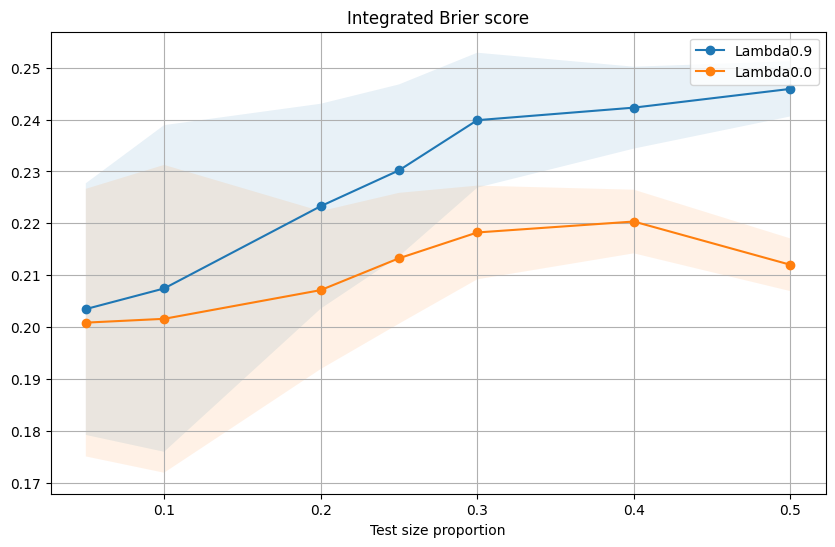

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))

for res, label in ((res2_is, "Lambda0.9"), (res2_lm, "Lambda0.0")):
    mean = res.mean(axis=0)
    std = res.std(axis=0) / np.sqrt(num_exps)
    ax.plot(sizes, mean, marker="o", label=label)
    ax.fill_between(sizes, mean - std, mean + std, alpha=0.1)

ax.legend()
ax.grid()
ax.set_title("Integrated Brier score")
ax.set_xlabel("Test size proportion")

Text(0.5, 0, 'Number of patients')

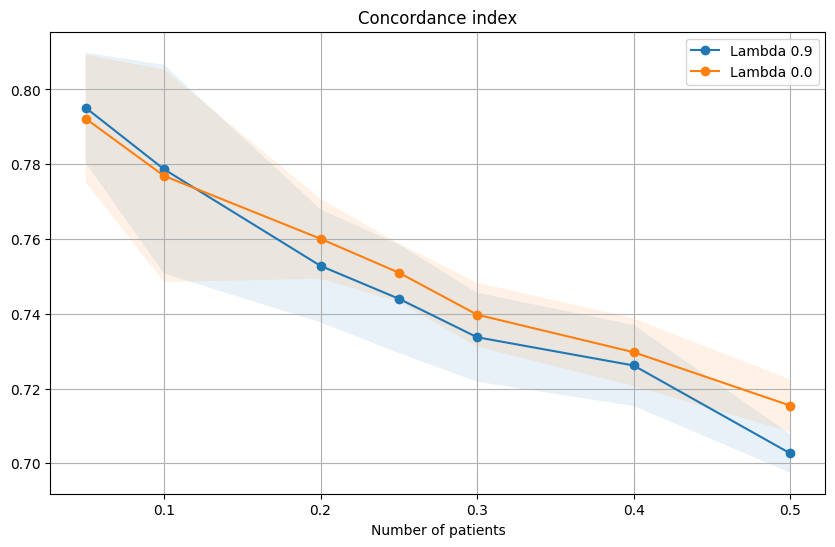

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))

for res, label in ((res3_is, "Lambda 0.9"), (res3_lm, "Lambda 0.0")):
    mean = res.mean(axis=0)
    std = res.std(axis=0) / np.sqrt(num_exps)
    ax.plot(sizes, mean, marker="o", label=label)
    ax.fill_between(sizes, mean - std, mean + std, alpha=0.1)

ax.legend()
ax.grid()
ax.set_title("Concordance index")
ax.set_xlabel("Number of patients")

In [26]:
train_gen.y

array([[[0., 0., 1., 0., 0.],
        [0., 1., 0., 0., 0.],
        [1., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]],

       [[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]],

       [[0., 0., 1., 0., 0.],
        [0., 1., 0., 0., 0.],
        [1., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]],

       ...,

       [[0., 1., 0., 0., 0.],
        [1., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]],

       [[0., 1., 0., 0., 0.],
        [1., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]],

       [[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]]])

In [29]:
train_gen.mask

array([[[ True,  True,  True,  True,  True],
        [ True,  True,  True,  True,  True],
        [ True,  True,  True,  True,  True],
        [False, False, False, False, False],
        [False, False, False, False, False]],

       [[ True,  True,  True,  True,  True],
        [ True,  True,  True,  True,  True],
        [ True,  True,  True,  True,  True],
        [ True,  True,  True,  True,  True],
        [False, False, False, False, False]],

       [[ True,  True,  True,  True,  True],
        [ True,  True,  True,  True,  True],
        [ True,  True,  True,  True,  True],
        [False, False, False, False, False],
        [False, False, False, False, False]],

       ...,

       [[ True,  True,  True,  True,  True],
        [ True,  True,  True,  True,  True],
        [False, False, False, False, False],
        [False, False, False, False, False],
        [False, False, False, False, False]],

       [[ True,  True,  True,  True,  True],
        [ True,  True,  True,  Tru

In [30]:
train_gen.cs

array([False,  True, False,  True, False,  True,  True, False,  True,
        True, False,  True,  True, False,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True, False,  True,  True,
        True,  True,  True,  True,  True, False, False,  True,  True,
       False, False,  True, False, False,  True,  True, False, False,
        True, False,  True,  True,  True,  True,  True,  True,  True,
       False, False, False, False,  True,  True,  True,  True, False,
        True, False, False, False, False, False, False, False,  True,
       False,  True, False,  True,  True,  True, False,  True,  True,
       False,  True,  True,  True,  True,  True, False,  True,  True,
       False,  True,  True, False,  True, False,  True, False,  True,
        True, False, False,  True, False, False,  True, False, False,
        True,  True,  True,  True, False, False, False,  True,  True,
        True,  True,  True,  True,  True, False,  True, False, False,
        True, False,